# Images and segmentations

Behind every profile there are images and segmentations. {func}`~mantispy.io.read_plate` reads a plate of them
into a {class}`~spatialdata.SpatialData` object: fields of view as Images, the CellProfiler objects as Labels,
and the cell-level measurements as a Table that annotates them.

{func}`~mantispy.ds.jump_plate` is that call on two fields of view of well `O09` of the JUMP plate `BR00121438`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from spatialdata import get_pyramid_levels
from spatialdata.transformations import get_transformation

import mantispy as mt

sdata = mt.ds.jump_plate()
sdata

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/ETcli4Pw/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/tim.treis/Documents/GitHub/mantispy-wt-reorg/src/mantispy/io/_gallery.py:355: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  [_prefix(pd.read_csv(file), "Cells").assign(Metadata_Key=file.parent.name) for file in files],
/Users/tim.treis/Documents/GitHub/mantispy-wt-reorg/src/mantispy/io/_gallery.py:355: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  [_prefix(pd.read_csv(file), "Cells").assign(Metadata_Key=file.parent.name) for file in files],


SpatialData object
├── Images
│     ├── 'BR00121438_O09_s1_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     └── 'BR00121438_O09_s2_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
├── Labels
│     ├── 'BR00121438_O09_s1_cells': DataArray[yx] (1080, 1080)
│     ├── 'BR00121438_O09_s1_cytoplasm': DataArray[yx] (1080, 1080)
│     ├── 'BR00121438_O09_s1_nuclei': DataArray[yx] (1080, 1080)
│     ├── 'BR00121438_O09_s2_cells': DataArray[yx] (1080, 1080)
│     ├── 'BR00121438_O09_s2_cytoplasm': DataArray[yx] (1080, 1080)
│     └── 'BR00121438_O09_s2_nuclei': DataArray[yx] (1080, 1080)
└── Tables
      └── 'cells': AnnData (284, 1989)
with coordinate systems:
    ▸ 'BR00121438', with elements:
        BR00121438_O09_s1_image (Images), BR00121438_O09_s2_image (Images), BR00121438_O09_s1_cells (Labels), BR00121438_O09_s1_cytoplasm (Labels), BR00121438_O09_s1_nuclei (Labels), BR00121438_O09_s2_cells (Labels), BR00121438_O09_s2_cytoplasm (Labels), BR0012

## Coordinate systems

Every element sits in coordinate systems for its own field, its well and the plate. The well frame lays the
fields of a well out where the microscope stage found them, with nothing resampled.

In [2]:
sorted(sdata.coordinate_systems)

['BR00121438', 'BR00121438_O09', 'BR00121438_O09_s1', 'BR00121438_O09_s2']

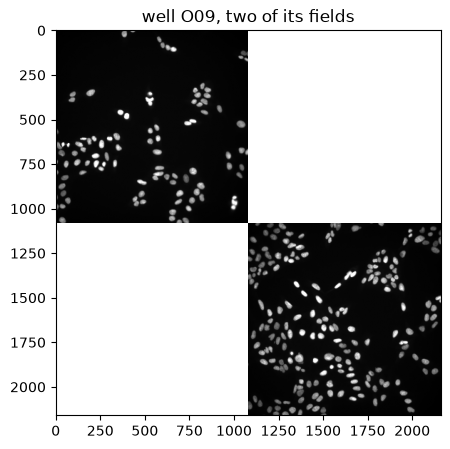

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
for image in sdata.images.values():
    offset = get_transformation(image, "BR00121438_O09").to_affine_matrix(input_axes=("y", "x"), output_axes=("y", "x"))
    y, x = offset[0, 2], offset[1, 2]
    dna = np.asarray(get_pyramid_levels(image, n=2).sel(c="DNA"))
    ax.imshow(dna, extent=(x, x + 1080, y + 1080, y), cmap="gray", vmax=np.percentile(dna, 99.5))
ax.set(xlim=(0, 2160), ylim=(2160, 0), title="well O09, two of its fields")
plt.show()

## Images and labels

The image of a field carries one named channel per imaging channel, five fluorescent and three brightfield. The labels carry CellProfiler object numbers, so the
rows of the cell table join straight onto them.

In [4]:
image = get_pyramid_levels(sdata["BR00121438_O09_s1_image"], n=0)
list(image.coords["c"].values)

[np.str_('Brightfield_L'),
 np.str_('Brightfield_H'),
 np.str_('Brightfield'),
 np.str_('RNA'),
 np.str_('Mito'),
 np.str_('ER'),
 np.str_('DNA'),
 np.str_('AGP')]

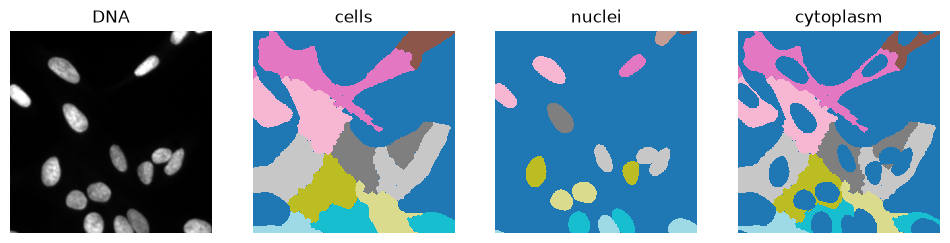

In [5]:
window = np.s_[300:600, 300:600]
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
dna = np.asarray(image.sel(c="DNA"))[window]
axes[0].imshow(dna, cmap="gray", vmax=np.percentile(dna, 99.5))
axes[0].set_title("DNA")
for ax, name in zip(axes[1:], ("cells", "nuclei", "cytoplasm"), strict=True):
    ax.imshow(np.asarray(sdata[f"BR00121438_O09_s1_{name}"])[window], cmap="tab20", interpolation="nearest")
    ax.set_title(name)
for ax in axes:
    ax.set_axis_off()
plt.show()

Cytoplasm is the cell mask minus the nucleus mask, as CellProfiler defines it.

## The table

`cells` holds one row per segmented cell, with the cell's own measurements as columns. It is an
ordinary {class}`~anndata.AnnData`, and its `var` is annotated with what each feature name encodes, as
{func}`~mantispy.io.read_profiles` annotates a profile read from disk.

In [6]:
cells = sdata.tables["cells"]
cells

AnnData object with n_obs × n_vars = 284 × 1989
    obs: 'Metadata_ImageNumber', 'Metadata_ObjectNumber', 'Metadata_Well', 'Metadata_Site', 'region'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy', 'spatialdata_attrs'
    layers: None (.X)

In [7]:
cells.var.head()

,object,feature_group,feature,channel,scale,angle,gray_levels,radial_bin,params,is_feature
Cells_AreaShape_Area,Cells,AreaShape,Area,NaN,NaN,NaN,NaN,NaN,NaN,True
Cells_AreaShape_BoundingBoxArea,Cells,AreaShape,BoundingBoxArea,NaN,NaN,NaN,NaN,NaN,NaN,True
Cells_AreaShape_Compactness,Cells,AreaShape,Compactness,NaN,NaN,NaN,NaN,NaN,NaN,True
Cells_AreaShape_Eccentricity,Cells,AreaShape,Eccentricity,NaN,NaN,NaN,NaN,NaN,NaN,True
Cells_AreaShape_EquivalentDiameter,Cells,AreaShape,EquivalentDiameter,NaN,NaN,NaN,NaN,NaN,NaN,True


`region` names the Labels element each row annotates, and `Metadata_ObjectNumber` the label value inside it:

In [8]:
cells.obs[["region", "Metadata_ObjectNumber"]].head()

,region,Metadata_ObjectNumber
BR00121438_O09_s1_cells:1,BR00121438_O09_s1_cells,1
BR00121438_O09_s1_cells:2,BR00121438_O09_s1_cells,2
BR00121438_O09_s1_cells:3,BR00121438_O09_s1_cells,3
BR00121438_O09_s1_cells:4,BR00121438_O09_s1_cells,4
BR00121438_O09_s1_cells:5,BR00121438_O09_s1_cells,5


## Reading a plate

A gallery source needs the accession directory, the batch and the plate barcode, which is what
{func}`~mantispy.ds.jump_plate` passes:

```python
sdata = mt.io.read_plate(
    "cpg0016-jump/source_4",
    "BR00121438",
    batch="2021_04_26_Batch1",
    wells=["O09"],
)
```

`wells` defaults to every well whose images are present, so a partial download reads back as itself.
The gallery publishes one-pixel object outlines rather than segmentation masks, so the Labels are reconstructed
from them. A component is accepted only when exactly one object centroid falls in it and its area is close to the
area CellProfiler measured. Rows whose object was not reconstructed are dropped, so every label stands for one
object.

A plate straight out of a pipeline run needs only its folder:

```python
sdata = mt.io.read_plate("run_export/Plate1")
```

Nothing is reconstructed on that path. The `ExportForSpatialData` module writes real label arrays, a per-cell
table already joined across compartments, and a manifest in the table's `uns` listing what it wrote.

Element names carry the plate barcode, so two plates concatenate without renaming, with
`spatialdata.concatenate([first, second], concatenate_tables=True)`.